Hierarchical Rao-Style PC-CNN — Joint Supervised Inference Experiment

Training uses one recurrent inference process per image. Predictive errors e0/e1/e2 and the class error are active together from the first inference step.
Validation and test use image-only predictive-coding inference; labels are used only outside the model for metrics.
No backpropagation, optimizer, or autograd-based learning is used.

In [1]:
import copy
import math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from collections import defaultdict
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Subset

import src.data_cleaning_and_preprocessing._model_ready_dataset as model_ready_dataset
from archive.dataset.tiny_imagenet_dataset import TinyImageNetLoader
from src.pc_supervised_rao_joint_inference_v1 import HierarchicalPCCNN

## Configuration

In [2]:
SEED = 42
BATCH_SIZE = 16
IMAGE_SIZE = 64

NUM_CLASSES = 5
TRAIN_IMAGES_PER_CLASS = 150
VAL_IMAGES_PER_CLASS = 50
TEST_IMAGES_PER_CLASS = 50

PC_EPOCHS = 15
INFERENCE_STEPS = 30
SIGMA_CLASS_SQ = 0.5
CLASS_LEARNING_RATE = 0.01
CLASS_WEIGHT_DECAY = 0.001

In [3]:
if torch.cuda.is_available(): device = torch.device("cuda")
elif torch.backends.mps.is_available(): device = torch.device("mps")
else: device = torch.device("cpu")

torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
if torch.backends.mps.is_available() and hasattr(torch.mps, "manual_seed"): torch.mps.manual_seed(SEED)

print("Device:", device)

Device: mps


## Dataset and stratified train/validation/test subsets

In [4]:
cleaned_tiny_imagenet = model_ready_dataset.ModelReadyDatasetLoader(TinyImageNetLoader(seed=SEED), image_size=IMAGE_SIZE).load()
train_dataset = cleaned_tiny_imagenet[0]
test_dataset = cleaned_tiny_imagenet[1]
selected_classes = list(range(NUM_CLASSES))

print("Full training dataset:", len(train_dataset))
print("Full held-out dataset:", len(test_dataset))

Full training dataset: 99953
Full held-out dataset: 9993


In [5]:
class_indices = defaultdict(list)
for i in range(len(train_dataset)):
    _, label = train_dataset[i]
    label = int(label)
    if label in selected_classes: class_indices[label].append(i)

split_generator = torch.Generator().manual_seed(SEED)
train_indices, val_indices = [], []

for class_id in selected_classes:
    available_indices = class_indices[class_id]
    required_images = TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS
    if len(available_indices) < required_images: raise ValueError(f"Class {class_id} has only {len(available_indices)} images, but {required_images} are required.")
    permutation = torch.randperm(len(available_indices), generator=split_generator)
    train_indices.extend([available_indices[i] for i in permutation[:TRAIN_IMAGES_PER_CLASS].tolist()])
    val_indices.extend([available_indices[i] for i in permutation[TRAIN_IMAGES_PER_CLASS:TRAIN_IMAGES_PER_CLASS + VAL_IMAGES_PER_CLASS].tolist()])

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

assert len(set(train_indices).intersection(set(val_indices))) == 0
assert len(train_subset) == NUM_CLASSES * TRAIN_IMAGES_PER_CLASS
assert len(val_subset) == NUM_CLASSES * VAL_IMAGES_PER_CLASS

train_loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, generator=train_loader_generator)
train_eval_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

K2_DECAYS_PER_EPOCH = 1.5
K2_DECAY_INTERVAL = max(1, round(len(train_subset) / K2_DECAYS_PER_EPOCH))

print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("k2 decays per epoch:", K2_DECAYS_PER_EPOCH)
print("k2 decay interval:", K2_DECAY_INTERVAL)

Training images: 750
Validation images: 250
Training batches: 47
Validation batches: 16
k2 decays per epoch: 1.5
k2 decay interval: 500


In [6]:
test_class_indices = defaultdict(list)
for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    label = int(label)
    if label in selected_classes: test_class_indices[label].append(i)

test_generator = torch.Generator().manual_seed(SEED)
test_indices = []
for class_id in selected_classes:
    available_indices = test_class_indices[class_id]
    if len(available_indices) < TEST_IMAGES_PER_CLASS: raise ValueError(f"Test class {class_id} has only {len(available_indices)} images, but {TEST_IMAGES_PER_CLASS} were requested.")
    permutation = torch.randperm(len(available_indices), generator=test_generator)
    test_indices.extend([available_indices[i] for i in permutation[:TEST_IMAGES_PER_CLASS].tolist()])

test_subset = Subset(test_dataset, test_indices)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)

print("Test images:", len(test_subset))
print("Test batches:", len(test_loader))

Test images: 250
Test batches: 16


## Model

In [7]:
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
if torch.backends.mps.is_available() and hasattr(torch.mps, "manual_seed"): torch.mps.manual_seed(SEED)

model = HierarchicalPCCNN(num_classes=NUM_CLASSES, input_size=IMAGE_SIZE, inference_steps=INFERENCE_STEPS, sigma_class_sq=SIGMA_CLASS_SQ, class_learning_rate=CLASS_LEARNING_RATE, lambda_class=CLASS_WEIGHT_DECAY, k2_decay_interval=K2_DECAY_INTERVAL).to(device)

initial_u1 = model.level1["conv"].weight.detach().cpu().clone()
initial_u2 = model.level2["conv"].weight.detach().cpu().clone()
initial_u3 = model.level3["conv"].weight.detach().cpu().clone()
initial_wc = model.classifier.weight.detach().cpu().clone()
initial_bc = model.classifier.bias.detach().cpu().clone()

print("Joint inference steps:", model.inference_steps)
print("sigma_class_sq:", model.sigma_class_sq)
print("class_learning_rate:", model.class_learning_rate)
print("lambda_class:", model.lambda_class)
print("k2 decay interval:", model.k2_decay_interval)
print("Total unique parameters:", sum(parameter.numel() for parameter in model.parameters()))
print("Autograd-enabled parameters:", sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad))
print("r3 size:", (256, model.r3_size, model.r3_size))
print("pooled classifier size:", (256, model.classifier_spatial_size, model.classifier_spatial_size))
print("classifier feature dim:", model.classifier_feature_dim)
print("classifier weight shape:", tuple(model.classifier.weight.shape))

Joint inference steps: 30
sigma_class_sq: 0.5
class_learning_rate: 0.01
lambda_class: 0.001
k2 decay interval: 500
Total unique parameters: 353125
Autograd-enabled parameters: 0
r3 size: (256, 8, 8)
pooled classifier size: (256, 4, 4)
classifier feature dim: 4096
classifier weight shape: (5, 4096)


## Image-only evaluation function

Validation/test labels are never passed into model inference here.

In [8]:
@torch.no_grad()
def evaluate_model(model: HierarchicalPCCNN, data_loader, device, name=""):
    total_loss = total_correct = total_images = total_steps = total_converged = 0
    model.eval()

    for images, labels in tqdm(data_loader, desc=f"Evaluation Joint Rao PC-CNN - {name}"):
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)

        result = model.classify_batch(images)

        probabilities = result["probabilities"]
        predictions = result["predictions"]

        true_probabilities = probabilities[torch.arange(labels.shape[0], device=labels.device), labels]
        loss = -torch.log(true_probabilities.clamp_min(1e-8)).mean().item()

        total_loss += loss * labels.shape[0]
        total_correct += (predictions == labels).sum().item()
        total_images += labels.shape[0]
        total_steps += sum(result["inference_steps"])
        total_converged += sum(int(value) for value in result["converged"])

    return total_loss / total_images, 100.0 * total_correct / total_images, total_steps / total_images, 100.0 * total_converged / total_images


## Reconstruction and all latent feature maps

In [9]:
# MEAN = torch.tensor(getattr(train_dataset, "mean", [0.0, 0.0, 0.0])).view(3, 1, 1)
# STD = torch.tensor(getattr(train_dataset, "std", [1.0, 1.0, 1.0])).view(3, 1, 1)

@torch.no_grad()
def show_all_latent_feature_maps(model: HierarchicalPCCNN, dataset, device, image_index=0, columns=16):
    image, label = dataset[image_index]
    model.eval()
    result = model.reconstruct(image.to(device))

    print("True Class:", int(label))
    print("Predicted Class:", result["predicted_class"])
    print("r1 shape:", result["r1"].shape)
    print("r2 shape:", result["r2"].shape)
    print("r3 shape:", result["r3"].shape)

    def to_display(tensor):
        tensor = tensor.detach().cpu() #* STD + MEAN
        return tensor.clamp(0, 1).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(to_display(image)); axes[0].set_title(f"Original | Class {int(label)}"); axes[0].axis("off")
    axes[1].imshow(to_display(result["reconstruction"])); axes[1].set_title(f"Reconstructed | Predicted {result['predicted_class']}"); axes[1].axis("off")
    plt.tight_layout(); plt.show()

    def plot_all_channels(state, layer_name, columns=16):
        state = state.detach().cpu()
        if state.ndim == 4: state = state.squeeze(0)
        num_channels = state.shape[0]
        rows = math.ceil(num_channels / columns)
        fig, axes = plt.subplots(rows, columns, figsize=(columns * 1.5, rows * 1.5))
        axes = axes.flatten()
        for channel in range(num_channels):
            feature_map = state[channel]
            min_value, max_value = feature_map.min(), feature_map.max()
            display_map = (feature_map - min_value) / (max_value - min_value + 1e-8)
            axes[channel].imshow(display_map, cmap="viridis")
            axes[channel].set_title(f"{layer_name}-{channel}", fontsize=7)
            axes[channel].axis("off")
        for channel in range(num_channels, len(axes)): axes[channel].axis("off")
        plt.suptitle(f"{layer_name} — All {num_channels} Feature Maps", fontsize=18)
        plt.tight_layout(); plt.show()

    plot_all_channels(result["r1"], "r1", columns)
    plot_all_channels(result["r2"], "r2", columns)
    plot_all_channels(result["r3"], "r3", columns)

In [ ]:
show_all_latent_feature_maps(model, val_subset, device, image_index=3, columns=16)

## Training

Important: the per-image class loss below is measured on the label-conditioned JOINT state.
Epoch train/validation accuracy is measured separately with image-only inference, matching test-time use.

In [10]:
history = []

best_val_loss = float("inf")
best_val_accuracy_at_best_loss = -1.0
best_epoch = None
best_model_state = None
best_k2 = None
best_training_input_count = None

peak_val_accuracy = -1.0
peak_val_accuracy_epoch = None


for epoch in range(PC_EPOCHS):
    total_error_0 = 0.0
    total_error_1 = 0.0
    total_error_2 = 0.0
    total_class_error = 0.0
    total_class_loss = 0.0

    total_r1_rms = 0.0
    total_r2_rms = 0.0
    total_r3_rms = 0.0

    total_images = 0

    model.train()

    for images, labels in tqdm(train_loader, desc=f"Joint Rao PC-CNN Epoch {epoch + 1}/{PC_EPOCHS}"):

        for image, label in zip(images, labels):
            image = image.to(device)
            label = label.to(device=device, dtype=torch.long)

            result = model(image, label)

            total_error_0 += result["error_0"]
            total_error_1 += result["error_1"]
            total_error_2 += result["error_2"]

            total_class_error += result["class_error"]
            total_class_loss += result["class_loss"]

            total_r1_rms += torch.sqrt(torch.mean(result["r1"] ** 2)).item()
            total_r2_rms += torch.sqrt(torch.mean(result["r2"] ** 2)).item()
            total_r3_rms += torch.sqrt(torch.mean(result["r3"] ** 2)).item()

            total_images += 1


    mean_error_0 = total_error_0 / total_images
    mean_error_1 = total_error_1 / total_images
    mean_error_2 = total_error_2 / total_images

    mean_class_error = total_class_error / total_images
    mean_class_loss = total_class_loss / total_images

    mean_r1_rms = total_r1_rms / total_images
    mean_r2_rms = total_r2_rms / total_images
    mean_r3_rms = total_r3_rms / total_images


    train_loss, train_accuracy, train_steps, train_convergence = evaluate_model(
        model, train_eval_loader, device, "Train"
    )

    val_loss, val_accuracy, val_steps, val_convergence = evaluate_model(
        model, val_loader, device, "Validation"
    )


    history.append({
        "epoch": epoch + 1,

        "joint_e0": mean_error_0,
        "joint_e1": mean_error_1,
        "joint_e2": mean_error_2,

        "joint_r1_rms": mean_r1_rms,
        "joint_r2_rms": mean_r2_rms,
        "joint_r3_rms": mean_r3_rms,

        "joint_class_error": mean_class_error,
        "joint_class_loss": mean_class_loss,

        "train_loss": train_loss,
        "train_accuracy": train_accuracy,

        "val_loss": val_loss,
        "val_accuracy": val_accuracy,

        "k2": model.k2
    })


    if val_accuracy > peak_val_accuracy:
        peak_val_accuracy = val_accuracy
        peak_val_accuracy_epoch = epoch + 1


    is_better = val_loss < best_val_loss or (
        val_loss == best_val_loss and val_accuracy > best_val_accuracy_at_best_loss
    )

    if is_better:
        best_val_loss = val_loss
        best_val_accuracy_at_best_loss = val_accuracy
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        best_k2 = model.k2
        best_training_input_count = model.training_input_count


    print(
        f"Epoch {epoch + 1}/{PC_EPOCHS} | "
        f"Joint e0: {mean_error_0:.6f} | "
        f"Joint e1: {mean_error_1:.6f} | "
        f"Joint e2: {mean_error_2:.6f} | "
        f"Joint Class e: {mean_class_error:.6f}"
    )

    print(
        f"Joint r1 RMS: {mean_r1_rms:.6f} | "
        f"Joint r2 RMS: {mean_r2_rms:.6f} | "
        f"Joint r3 RMS: {mean_r3_rms:.6f}"
    )

    print(
        f"Joint Class Loss: {mean_class_loss:.4f} | "
        f"FREE Train Acc: {train_accuracy:.2f}% | "
        f"FREE Val Acc: {val_accuracy:.2f}% | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"k2: {model.k2:.8f}"
    )

    print(
        f"Train Convergence: {train_convergence:.2f}% | "
        f"Val Convergence: {val_convergence:.2f}%"
    )

Joint Rao PC-CNN Epoch 1/15:   0%|          | 0/47 [00:00<?, ?it/s]

Evaluation Joint Rao PC-CNN - Train:   0%|          | 0/47 [00:00<?, ?it/s]

Evaluation Joint Rao PC-CNN - Validation:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/15 | Joint e0: 0.142943 | Joint e1: 0.048434 | Joint e2: 0.026076 | Joint Class e: 0.337895
Joint r1 RMS: 0.168126 | Joint r2 RMS: 0.074385 | Joint r3 RMS: 0.044562
Joint Class Loss: 1.1451 | FREE Train Acc: 23.87% | FREE Val Acc: 20.00% | Train Loss: 1.5942 | Val Loss: 1.5986 | k2: 0.98522167
Train Convergence: 0.00% | Val Convergence: 0.00%


Joint Rao PC-CNN Epoch 2/15:   0%|          | 0/47 [00:00<?, ?it/s]

...

Epoch 14/15 | Joint e0: 0.077457 | Joint e1: 0.037471 | Joint e2: 0.019340 | Joint Class e: 0.034396
Joint r1 RMS: 0.160229 | Joint r2 RMS: 0.067298 | Joint r3 RMS: 0.041921
Joint Class Loss: 0.0711 | FREE Train Acc: 44.27% | FREE Val Acc: 39.60% | Train Loss: 1.4809 | Val Loss: 1.5082 | k2: 0.73149795
Train Convergence: 0.00% | Val Convergence: 0.00%


Joint Rao PC-CNN Epoch 15/15:   0%|          | 0/47 [00:00<?, ?it/s]

Evaluation Joint Rao PC-CNN - Train:   0%|          | 0/47 [00:00<?, ?it/s]

Evaluation Joint Rao PC-CNN - Validation:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 15/15 | Joint e0: 0.076249 | Joint e1: 0.037907 | Joint e2: 0.019370 | Joint Class e: 0.032993
Joint r1 RMS: 0.160430 | Joint r2 RMS: 0.067362 | Joint r3 RMS: 0.041941
Joint Class Loss: 0.0681 | FREE Train Acc: 44.67% | FREE Val Acc: 39.60% | Train Loss: 1.4781 | Val Loss: 1.5065 | k2: 0.72068763
Train Convergence: 0.00% | Val Convergence: 0.00%


## Weight changes after training

In [11]:
print("AFTER TRAINING")
print("Inference Steps:", model.inference_steps)
print("training_input_count:", model.training_input_count)
print("k2:", model.k2)
print("U1 norm:", model.level1["conv"].weight.norm().item())
print("U2 norm:", model.level2["conv"].weight.norm().item())
print("U3 norm:", model.level3["conv"].weight.norm().item())
print("Wc norm:", model.classifier.weight.norm().item())
print("bc norm:", model.classifier.bias.norm().item())
print("U1 change:", torch.norm(model.level1["conv"].weight.detach().cpu() - initial_u1).item())
print("U2 change:", torch.norm(model.level2["conv"].weight.detach().cpu() - initial_u2).item())
print("U3 change:", torch.norm(model.level3["conv"].weight.detach().cpu() - initial_u3).item())
print("Wc change:", torch.norm(model.classifier.weight.detach().cpu() - initial_wc).item())
print("bc change:", torch.norm(model.classifier.bias.detach().cpu() - initial_bc).item())

AFTER TRAINING
Inference Steps: 30
training_input_count: 11250
k2: 0.7206876344718605
U1 norm: 1.7914546728134155
U2 norm: 2.470801591873169
U3 norm: 2.6082019805908203
Wc norm: 9.008223533630371
bc norm: 0.37971433997154236
U1 change: 1.6831036806106567
U2 change: 2.766160011291504
U3 change: 5.132174491882324
Wc change: 7.722898960113525
bc change: 0.37971433997154236


## Restore minimum-validation-loss checkpoint

In [ ]:
if best_model_state is None: raise RuntimeError("No model checkpoint was saved.")
model.load_state_dict(best_model_state)
model.k2 = best_k2
model.training_input_count = best_training_input_count
model.eval()

print("Best epoch by validation loss:", best_epoch)
print("Validation accuracy at best-loss checkpoint:", f"{best_val_accuracy_at_best_loss:.2f}%")
print("Best validation loss:", f"{best_val_loss:.4f}")
print("Peak validation accuracy observed:", f"{peak_val_accuracy:.2f}% at epoch {peak_val_accuracy_epoch}")
print("Best Wc norm:", model.classifier.weight.norm().item())
print("Best k2:", model.k2)

True Class: 0
Predicted Class: 1
r1 shape: torch.Size([32, 32, 32])
r2 shape: torch.Size([128, 16, 16])
r3 shape: torch.Size([256, 8, 8])


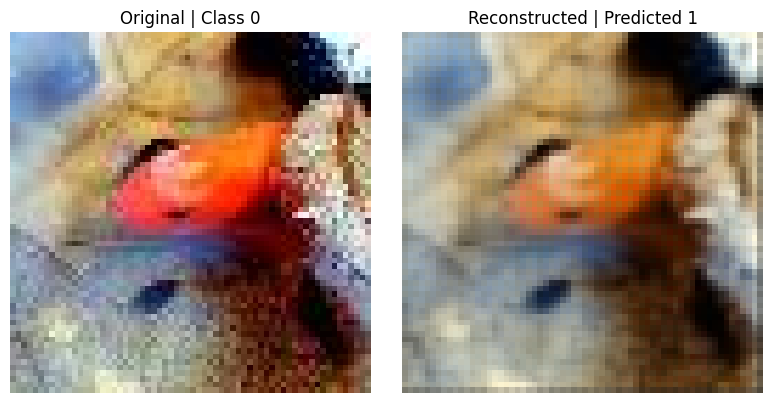

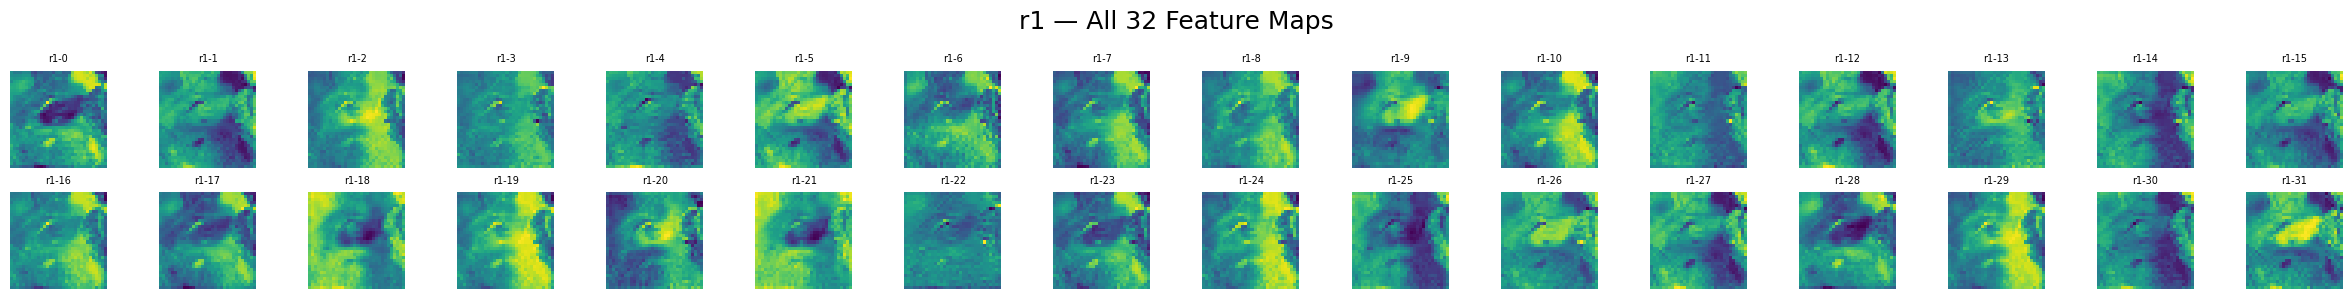

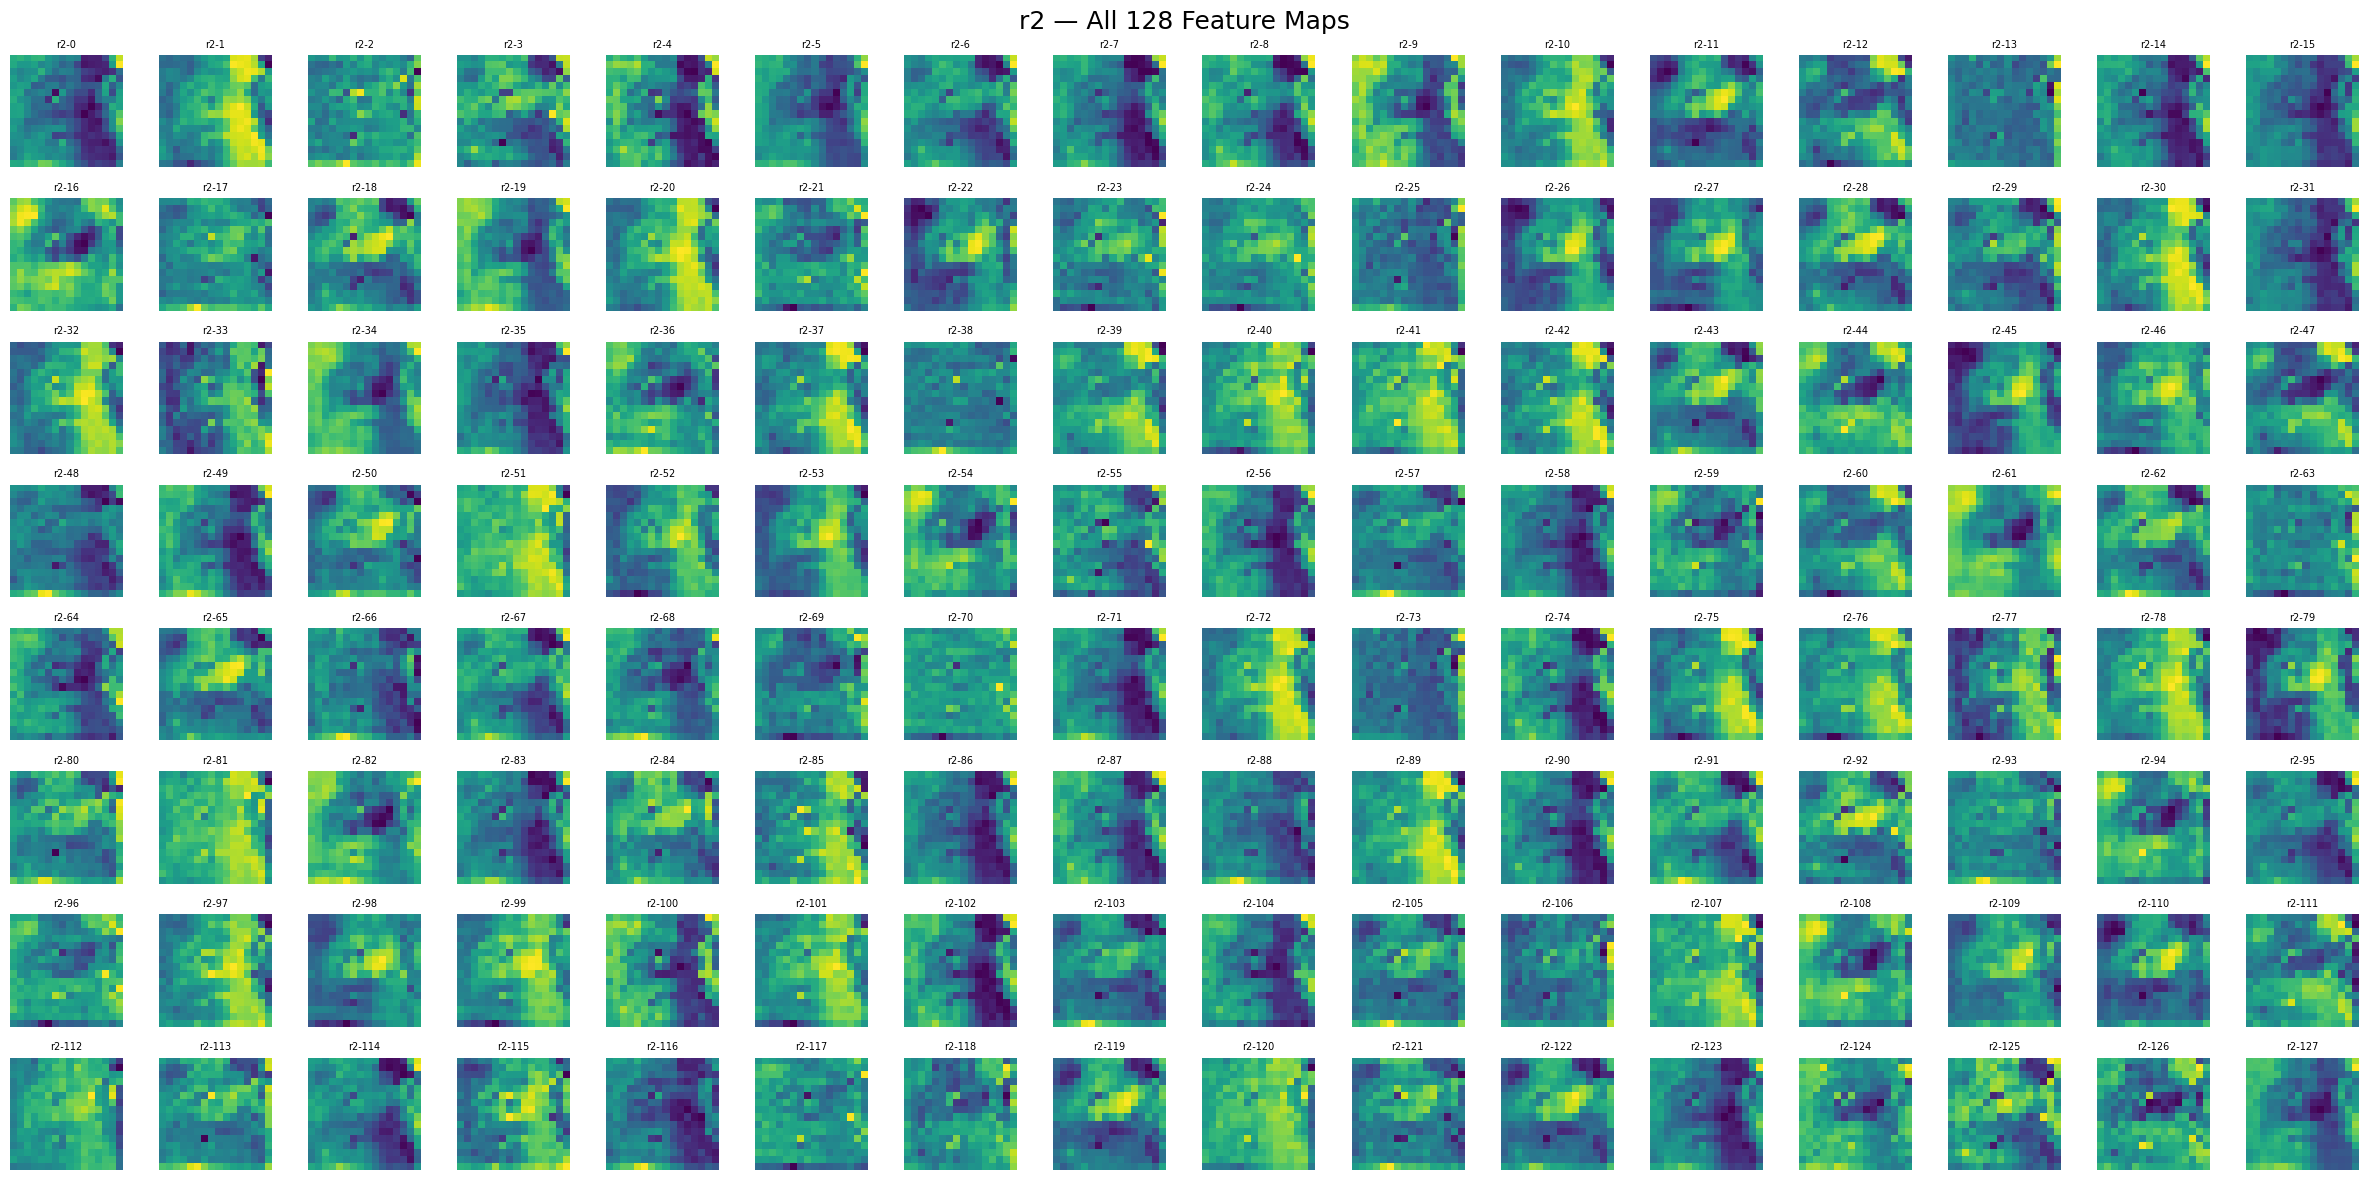

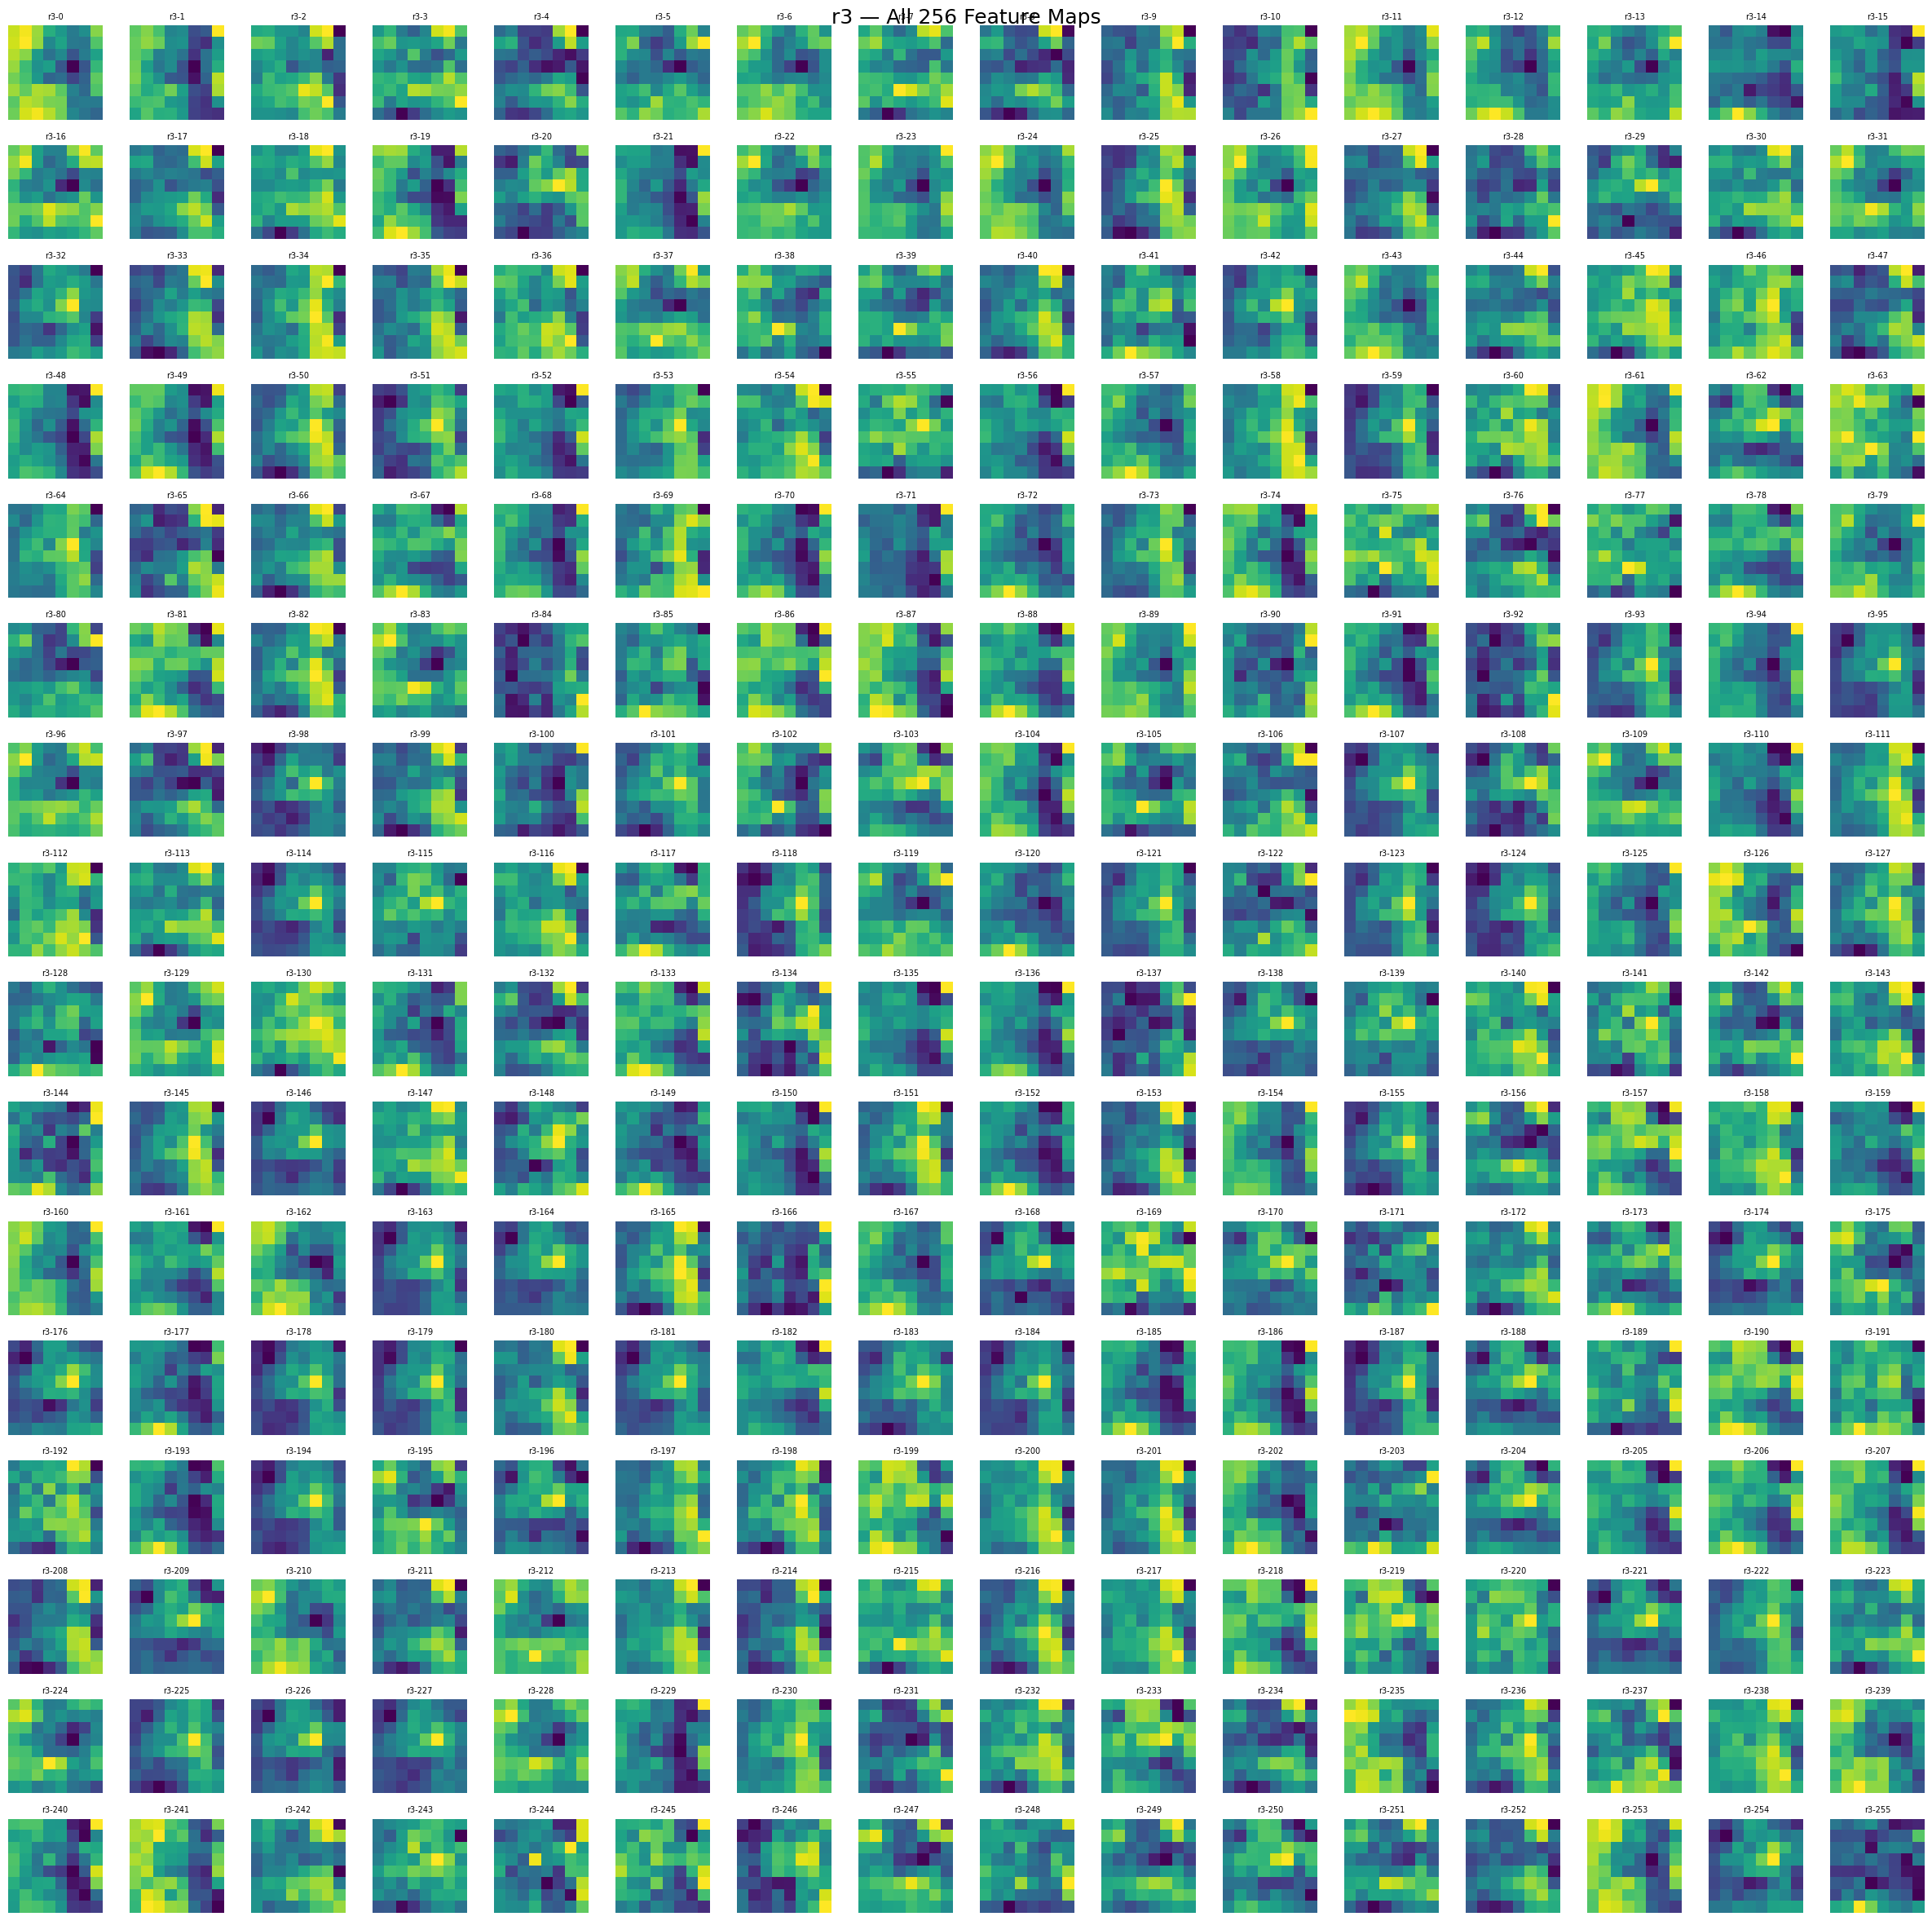

In [12]:
show_all_latent_feature_maps(model, val_subset, device, image_index=3, columns=16)

## Image-only inference-step comparison

In [ ]:
original_inference_steps = model.inference_steps
results_by_steps = {}
for steps in [20, 50, 100]:
    model.inference_steps = steps
    loss, accuracy, _, convergence = evaluate_model(model, val_loader, device, f"Validation {steps} Steps")
    results_by_steps[steps] = (loss, accuracy, convergence)
model.inference_steps = original_inference_steps

for steps, (loss, accuracy, convergence) in results_by_steps.items(): print(f"{steps} steps: Accuracy={accuracy:.2f}% | Loss={loss:.4f} | Convergence={convergence:.2f}%")

## Confidence diagnostics — image-only inference

In [13]:
@torch.no_grad()
def confidence_diagnostics(model, data_loader, device, name):
    model.eval()
    correct_confidences, wrong_confidences, true_class_probabilities = [], [], []
    for images, labels in tqdm(data_loader, desc=f"Confidence - {name}"):
        images = images.to(device)
        labels = labels.to(device=device, dtype=torch.long)
        result = model.classify_batch(images)
        probabilities = result["probabilities"]
        predictions = result["predictions"]
        confidences = probabilities.max(dim=1).values
        true_probs = probabilities[torch.arange(labels.shape[0], device=device), labels]
        correct_mask = predictions == labels
        wrong_mask = predictions != labels
        correct_confidences.extend(confidences[correct_mask].cpu().tolist())
        wrong_confidences.extend(confidences[wrong_mask].cpu().tolist())
        true_class_probabilities.extend(true_probs.cpu().tolist())

    print(name)
    print("Mean true-class probability:", sum(true_class_probabilities) / len(true_class_probabilities))
    print("Mean confidence on correct predictions:", sum(correct_confidences) / len(correct_confidences) if correct_confidences else 0.0)
    print("Mean confidence on wrong predictions:", sum(wrong_confidences) / len(wrong_confidences) if wrong_confidences else 0.0)

confidence_diagnostics(model, train_eval_loader, device, "TRAIN")
confidence_diagnostics(model, val_loader, device, "VALIDATION")

Confidence - TRAIN:   0%|          | 0/47 [00:00<?, ?it/s]

TRAIN
Mean true-class probability: 0.2325507565041383
Mean confidence on correct predictions: 0.2673095341938645
Mean confidence on wrong predictions: 0.2487212397606976


Confidence - VALIDATION:   0%|          | 0/16 [00:00<?, ?it/s]

VALIDATION
Mean true-class probability: 0.22692332999408246
Mean confidence on correct predictions: 0.2700928243422749
Mean confidence on wrong predictions: 0.24931862091781287


## Full FREE r3 train-vs-validation geometry

In [14]:
@torch.no_grad()
def collect_class_features(model, data_loader, device, num_classes):
    features_by_class = [[] for _ in range(num_classes)]
    model.eval()
    for images, labels in tqdm(data_loader, desc="Collecting FREE r3 Features"):
        for image, label in zip(images, labels):
            _, _, r3, _, _ = model.infer(image.to(device), label=None)
            features_by_class[int(label)].append(model.class_features(r3).squeeze(0).cpu())
    return [torch.stack(features) for features in features_by_class]

train_features_by_class = collect_class_features(model, train_eval_loader, device, NUM_CLASSES)
val_features_by_class = collect_class_features(model, val_loader, device, NUM_CLASSES)

In [15]:
@torch.no_grad()
def compare_feature_geometry(train_features_by_class, val_features_by_class):
    train_centroids = torch.stack([features.mean(dim=0) for features in train_features_by_class])
    val_centroids = torch.stack([features.mean(dim=0) for features in val_features_by_class])
    train_spread = torch.tensor([torch.norm(features - train_centroids[class_id], dim=1).mean().item() for class_id, features in enumerate(train_features_by_class)])
    val_spread_to_train = torch.tensor([torch.norm(features - train_centroids[class_id], dim=1).mean().item() for class_id, features in enumerate(val_features_by_class)])
    centroid_shift = torch.norm(val_centroids - train_centroids, dim=1)
    train_centroid_distances = torch.cdist(train_centroids, train_centroids)
    off_diagonal_mask = ~torch.eye(NUM_CLASSES, dtype=torch.bool)
    inter_class_distances = train_centroid_distances[off_diagonal_mask]
    mean_inter = inter_class_distances.mean().item()
    minimum_inter = inter_class_distances.min().item()
    mean_train_spread = train_spread.mean().item()
    mean_val_spread = val_spread_to_train.mean().item()
    train_separation = mean_inter / mean_train_spread
    val_separation = mean_inter / mean_val_spread

    def nearest_centroid_accuracy(features_by_class, centroids, metric="euclidean"):
        correct = total = 0
        normalized_centroids = F.normalize(centroids, dim=1)
        for class_id, features in enumerate(features_by_class):
            predictions = torch.cdist(features, centroids).argmin(dim=1) if metric == "euclidean" else (F.normalize(features, dim=1) @ normalized_centroids.T).argmax(dim=1)
            correct += (predictions == class_id).sum().item(); total += features.shape[0]
        return 100.0 * correct / total

    train_nc_euclidean = nearest_centroid_accuracy(train_features_by_class, train_centroids, "euclidean")
    val_nc_euclidean = nearest_centroid_accuracy(val_features_by_class, train_centroids, "euclidean")
    train_nc_cosine = nearest_centroid_accuracy(train_features_by_class, train_centroids, "cosine")
    val_nc_cosine = nearest_centroid_accuracy(val_features_by_class, train_centroids, "cosine")

    print("=" * 78)
    print("POOLED FREE r3 TRAIN vs VALIDATION REPRESENTATION DIAGNOSTICS")
    print("=" * 78)
    print(f"Mean TRAIN within-class spread          : {mean_train_spread:.4f}")
    print(f"Mean VAL distance to TRAIN centroid     : {mean_val_spread:.4f}")
    print(f"Mean TRAIN↔VAL centroid shift           : {centroid_shift.mean().item():.4f}")
    print(f"Mean TRAIN inter-class centroid distance: {mean_inter:.4f}")
    print(f"Minimum inter-class centroid distance   : {minimum_inter:.4f}")
    print(f"TRAIN separation ratio                  : {train_separation:.4f}")
    print(f"VALIDATION separation ratio             : {val_separation:.4f}")
    print("-" * 78)
    print(f"TRAIN nearest-centroid accuracy (Euclidean): {train_nc_euclidean:.2f}%")
    print(f"VAL nearest-centroid accuracy (Euclidean)  : {val_nc_euclidean:.2f}%")
    print(f"TRAIN nearest-centroid accuracy (Cosine)   : {train_nc_cosine:.2f}%")
    print(f"VAL nearest-centroid accuracy (Cosine)     : {val_nc_cosine:.2f}%")
    print("-" * 78)
    for class_id in range(NUM_CLASSES): print(f"Class {class_id:02d} | Train Spread: {train_spread[class_id]:.4f} | Val→Train Spread: {val_spread_to_train[class_id]:.4f} | Centroid Shift: {centroid_shift[class_id]:.4f}")
    print("=" * 78)

compare_feature_geometry(train_features_by_class, val_features_by_class)

POOLED FREE r3 TRAIN vs VALIDATION REPRESENTATION DIAGNOSTICS
Mean TRAIN within-class spread          : 1.0838
Mean VAL distance to TRAIN centroid     : 1.0961
Mean TRAIN↔VAL centroid shift           : 0.2357
Mean TRAIN inter-class centroid distance: 0.3869
Minimum inter-class centroid distance   : 0.2086
TRAIN separation ratio                  : 0.3570
VALIDATION separation ratio             : 0.3530
------------------------------------------------------------------------------
TRAIN nearest-centroid accuracy (Euclidean): 41.47%
VAL nearest-centroid accuracy (Euclidean)  : 36.80%
TRAIN nearest-centroid accuracy (Cosine)   : 46.13%
VAL nearest-centroid accuracy (Cosine)     : 40.00%
------------------------------------------------------------------------------
Class 00 | Train Spread: 1.4706 | Val→Train Spread: 1.3355 | Centroid Shift: 0.3010
Class 01 | Train Spread: 0.9488 | Val→Train Spread: 0.9412 | Centroid Shift: 0.2330
Class 02 | Train Spread: 1.0207 | Val→Train Spread: 0.9891 | 

## Balanced FREE vs JOINT r3 diagnostic

JOINT uses the true label and is diagnostic only. FREE is the representation used for validation/test classification.

In [16]:
@torch.no_grad()
def compare_free_vs_joint_r3(model, dataset, device, num_classes=20, samples_per_class=10, name=""):
    model.eval()
    free_by_class = [[] for _ in range(num_classes)]
    joint_by_class = [[] for _ in range(num_classes)]
    counts = [0] * num_classes
    errors = {"free_e0": [], "free_e1": [], "free_e2": [], "joint_e0": [], "joint_e1": [], "joint_e2": [], "free_r2_cos": [], "joint_r2_cos": []}

    for image, label in tqdm(dataset, desc=f"FREE vs JOINT r3 - {name}"):
        label = int(label)
        if label >= num_classes or counts[label] >= samples_per_class: continue
        image = image.to(device)
        label_tensor = torch.tensor(label, device=device, dtype=torch.long)

        r1_f, r2_f, r3_f, _, _ = model.infer(image, label=None)
        e0_f, e1_f, e2_f, _, pred_r2_f = model.prediction_errors(image, r1_f, r2_f, r3_f)

        r1_j, r2_j, r3_j, _, _ = model.infer(image, label=label_tensor)
        e0_j, e1_j, e2_j, _, pred_r2_j = model.prediction_errors(image, r1_j, r2_j, r3_j)

        free_by_class[label].append(model.class_features(r3_f).squeeze(0).cpu())
        joint_by_class[label].append(model.class_features(r3_j).squeeze(0).cpu())

        for key, tensor in [("free_e0", e0_f), ("free_e1", e1_f), ("free_e2", e2_f), ("joint_e0", e0_j), ("joint_e1", e1_j), ("joint_e2", e2_j)]: errors[key].append(torch.sqrt(torch.mean(tensor ** 2)).item())
        errors["free_r2_cos"].append(F.cosine_similarity(r2_f.flatten(1), pred_r2_f.flatten(1), dim=1).item())
        errors["joint_r2_cos"].append(F.cosine_similarity(r2_j.flatten(1), pred_r2_j.flatten(1), dim=1).item())

        counts[label] += 1
        if all(count >= samples_per_class for count in counts): break

    free_by_class = [torch.stack(features) for features in free_by_class]
    joint_by_class = [torch.stack(features) for features in joint_by_class]

    def geometry(features_by_class):
        centroids = torch.stack([features.mean(dim=0) for features in features_by_class])
        spreads = torch.tensor([torch.norm(features - centroids[class_id], dim=1).mean().item() for class_id, features in enumerate(features_by_class)])
        distances = torch.cdist(centroids, centroids)
        inter = distances[~torch.eye(num_classes, dtype=torch.bool)]
        mean_spread = spreads.mean().item(); mean_inter = inter.mean().item(); min_inter = inter.min().item()
        separation = mean_inter / mean_spread

        def nearest_centroid(metric):
            correct = total = 0
            normalized_centroids = F.normalize(centroids, dim=1)
            for class_id, features in enumerate(features_by_class):
                predictions = torch.cdist(features, centroids).argmin(dim=1) if metric == "euclidean" else (F.normalize(features, dim=1) @ normalized_centroids.T).argmax(dim=1)
                correct += (predictions == class_id).sum().item(); total += features.shape[0]
            return 100.0 * correct / total

        return {"spread": mean_spread, "inter": mean_inter, "min_inter": min_inter, "separation": separation, "nc_euclidean": nearest_centroid("euclidean"), "nc_cosine": nearest_centroid("cosine")}

    free, joint = geometry(free_by_class), geometry(joint_by_class)
    means = {key: sum(values) / len(values) for key, values in errors.items()}

    print("=" * 78)
    print("Name=", name)
    print("FREE vs JOINT r3 CLASS-SEPARATION DIAGNOSTIC")
    print("=" * 78)
    print(f"Images analyzed                     : {sum(counts)}")
    print(f"FREE within-class spread            : {free['spread']:.4f}")
    print(f"JOINT within-class spread           : {joint['spread']:.4f}")
    print(f"FREE inter-class centroid distance  : {free['inter']:.4f}")
    print(f"JOINT inter-class centroid distance : {joint['inter']:.4f}")
    print(f"FREE minimum inter-class distance   : {free['min_inter']:.4f}")
    print(f"JOINT minimum inter-class distance  : {joint['min_inter']:.4f}")
    print(f"FREE separation ratio               : {free['separation']:.4f}")
    print(f"JOINT separation ratio              : {joint['separation']:.4f}")
    print(f"FREE nearest-centroid Euclidean     : {free['nc_euclidean']:.2f}%")
    print(f"JOINT nearest-centroid Euclidean    : {joint['nc_euclidean']:.2f}%")
    print(f"FREE nearest-centroid Cosine        : {free['nc_cosine']:.2f}%")
    print(f"JOINT nearest-centroid Cosine       : {joint['nc_cosine']:.2f}%")
    print("-" * 78)
    print(f"FREE e0/e1/e2 RMS                   : {means['free_e0']:.6f} / {means['free_e1']:.6f} / {means['free_e2']:.6f}")
    print(f"JOINT e0/e1/e2 RMS                  : {means['joint_e0']:.6f} / {means['joint_e1']:.6f} / {means['joint_e2']:.6f}")
    print(f"FREE r2 ↔ predicted-r2 cosine       : {means['free_r2_cos']:.6f}")
    print(f"JOINT r2 ↔ predicted-r2 cosine      : {means['joint_r2_cos']:.6f}")
    print("=" * 78)
    return {"free": free, "joint": joint, "errors": means}

train_free_joint = compare_free_vs_joint_r3(model, train_subset, device, NUM_CLASSES, samples_per_class=10, name="TRAIN")
val_free_joint = compare_free_vs_joint_r3(model, val_subset, device, NUM_CLASSES, samples_per_class=10, name="VALIDATION")

FREE vs JOINT r3 - TRAIN:   0%|          | 0/750 [00:00<?, ?it/s]

Name= TRAIN
FREE vs JOINT r3 CLASS-SEPARATION DIAGNOSTIC
Images analyzed                     : 50
FREE within-class spread            : 1.0573
JOINT within-class spread           : 1.0570
FREE inter-class centroid distance  : 0.5264
JOINT inter-class centroid distance : 1.3651
FREE minimum inter-class distance   : 0.3224
JOINT minimum inter-class distance  : 1.2914
FREE separation ratio               : 0.4978
JOINT separation ratio              : 1.2914
FREE nearest-centroid Euclidean     : 62.00%
JOINT nearest-centroid Euclidean    : 100.00%
FREE nearest-centroid Cosine        : 68.00%
JOINT nearest-centroid Cosine       : 100.00%
------------------------------------------------------------------------------
FREE e0/e1/e2 RMS                   : 0.077172 / 0.038790 / 0.020120
JOINT e0/e1/e2 RMS                  : 0.077172 / 0.038789 / 0.020109
FREE r2 ↔ predicted-r2 cosine       : 0.943990
JOINT r2 ↔ predicted-r2 cosine      : 0.944052


FREE vs JOINT r3 - VALIDATION:   0%|          | 0/250 [00:00<?, ?it/s]

Name= VALIDATION
FREE vs JOINT r3 CLASS-SEPARATION DIAGNOSTIC
Images analyzed                     : 50
FREE within-class spread            : 1.0212
JOINT within-class spread           : 1.0209
FREE inter-class centroid distance  : 0.6034
JOINT inter-class centroid distance : 1.3918
FREE minimum inter-class distance   : 0.4184
JOINT minimum inter-class distance  : 1.3157
FREE separation ratio               : 0.5909
JOINT separation ratio              : 1.3633
FREE nearest-centroid Euclidean     : 58.00%
JOINT nearest-centroid Euclidean    : 100.00%
FREE nearest-centroid Cosine        : 68.00%
JOINT nearest-centroid Cosine       : 100.00%
------------------------------------------------------------------------------
FREE e0/e1/e2 RMS                   : 0.072908 / 0.036980 / 0.018597
JOINT e0/e1/e2 RMS                  : 0.072908 / 0.036979 / 0.018595
FREE r2 ↔ predicted-r2 cosine       : 0.954890
JOINT r2 ↔ predicted-r2 cosine      : 0.954874


## Balanced class-force vs predictive-force diagnostic at the FREE state

In [17]:
@torch.no_grad()
def diagnose_r3_force_alignment(model, dataset, device, num_classes=20, samples_per_class=10, name=""):
    model.eval()
    counts = [0] * num_classes
    values = {"e2": [], "e2_force": [], "class_force": [], "force_cosine": [], "r2_pred_cosine": []}

    for image, label in tqdm(dataset, desc=f"Balanced r3 force - {name}"):
        label = int(label)
        if counts[label] >= samples_per_class: continue
        image = image.to(device)
        label_tensor = torch.tensor(label, device=device, dtype=torch.long)

        r1, r2, r3, _, _ = model.infer(image, label=None)
        _, _, e2, _, predicted_r2 = model.prediction_errors(image, r1, r2, r3)
        e2_force = (model.k1 / model.sigma_bu_sq) * model.activation_derivative(r3) * model.level3["conv"](e2)
        _, _, _, e_class = model.class_prediction_error(r3, label_tensor)
        class_force = (model.k1 / model.sigma_class_sq) * model.class_feedback(e_class, r3)

        values["e2"].append(torch.sqrt(torch.mean(e2 ** 2)).item())
        values["e2_force"].append(torch.sqrt(torch.mean(e2_force ** 2)).item())
        values["class_force"].append(torch.sqrt(torch.mean(class_force ** 2)).item())
        values["force_cosine"].append(F.cosine_similarity(e2_force.flatten(1), class_force.flatten(1), dim=1).item())
        values["r2_pred_cosine"].append(F.cosine_similarity(r2.flatten(1), predicted_r2.flatten(1), dim=1).item())

        counts[label] += 1
        if all(count >= samples_per_class for count in counts): break

    mean = {key: sum(value) / len(value) for key, value in values.items()}
    print("=" * 72)
    print("Name=", name)
    print("BALANCED FREE-STATE r3 FORCE ALIGNMENT")
    print("=" * 72)
    print(f"Images analyzed                 : {sum(counts)}")
    print(f"Free e2 RMS                    : {mean['e2']:.6f}")
    print(f"r2 ↔ predicted-r2 cosine       : {mean['r2_pred_cosine']:.6f}")
    print(f"Pure e2 force RMS              : {mean['e2_force']:.8f}")
    print(f"Class force RMS                : {mean['class_force']:.8f}")
    print(f"Class / e2 force ratio         : {mean['class_force'] / (mean['e2_force'] + 1e-12):.4f}")
    print(f"e2-force ↔ class-force cosine  : {mean['force_cosine']:.6f}")
    print("=" * 72)
    return mean

train_force = diagnose_r3_force_alignment(model, train_subset, device, NUM_CLASSES, samples_per_class=10, name="TRAIN")
val_force = diagnose_r3_force_alignment(model, val_subset, device, NUM_CLASSES, samples_per_class=10, name="VALIDATION")

Balanced r3 force - TRAIN:   0%|          | 0/750 [00:00<?, ?it/s]

Name= TRAIN
BALANCED FREE-STATE r3 FORCE ALIGNMENT
Images analyzed                 : 50
Free e2 RMS                    : 0.020120
r2 ↔ predicted-r2 cosine       : 0.943990
Pure e2 force RMS              : 0.00754460
Class force RMS                : 0.01509109
Class / e2 force ratio         : 2.0002
e2-force ↔ class-force cosine  : 0.023606


Balanced r3 force - VALIDATION:   0%|          | 0/250 [00:00<?, ?it/s]

Name= VALIDATION
BALANCED FREE-STATE r3 FORCE ALIGNMENT
Images analyzed                 : 50
Free e2 RMS                    : 0.018597
r2 ↔ predicted-r2 cosine       : 0.954890
Pure e2 force RMS              : 0.00735255
Class force RMS                : 0.01518123
Class / e2 force ratio         : 2.0648
e2-force ↔ class-force cosine  : 0.018384


## Final restored-best evaluation

In [ ]:
train_loss, train_accuracy, train_steps, train_convergence = evaluate_model(model, train_eval_loader, device, "Train Final")
val_loss, val_accuracy, val_steps, val_convergence = evaluate_model(model, val_loader, device, "Validation Final")
test_loss, test_accuracy, test_steps, test_convergence = evaluate_model(model, test_loader, device, "Test")

print("FINAL RESTORED BEST MODEL")
print("Train Loss:", f"{train_loss:.4f}")
print("Train Accuracy:", f"{train_accuracy:.2f}%")
print("Validation Loss:", f"{val_loss:.4f}")
print("Validation Accuracy:", f"{val_accuracy:.2f}%")
print("Test Loss:", f"{test_loss:.4f}")
print("Test Accuracy:", f"{test_accuracy:.2f}%")
print("Test Convergence:", f"{test_convergence:.2f}%")